In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['XOM', 'CVX', 'COP', 'MPC', 'PSX', 'VLO']

prices = yf.download(tickers, start='2015-01-01', end='2024-01-01', auto_adjust=True)['Close']
prices.dropna(inplace=True)

print(prices.shape)
print(prices.head())

[*********************100%***********************]  6 of 6 completed

(2264, 6)
Ticker            COP        CVX        MPC        PSX        VLO        XOM
Date                                                                        
2015-01-02  47.917255  69.529381  32.555969  47.927788  32.627342  57.533428
2015-01-05  45.636803  66.750175  31.650059  45.030502  31.285690  55.959198
2015-01-06  43.752644  66.719322  31.337427  43.770805  30.903299  55.661709
2015-01-07  44.044659  66.663734  31.596779  43.963081  30.663479  56.225712
2015-01-08  45.143185  68.189209  32.339272  45.673599  32.419933  57.161575


In [2]:
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import itertools
import matplotlib.pyplot as plt

# Log-transform prices
log_prices = np.log(prices)

# --- TRAIN/TEST SPLIT --- 
# We do this NOW before touching any analysis
log_IS  = log_prices[log_prices.index <= '2020-12-31']
log_OOS = log_prices[log_prices.index >= '2021-01-01']

print(f"In-sample rows:     {len(log_IS)}  ({log_IS.index[0].date()} to {log_IS.index[-1].date()})")
print(f"Out-of-sample rows: {len(log_OOS)}  ({log_OOS.index[0].date()} to {log_OOS.index[-1].date()})")

# --- COINTEGRATION SCREENING (IN-SAMPLE ONLY) ---
tickers_list = list(log_IS.columns)
pairs = list(itertools.combinations(tickers_list, 2))

print(f"\nTesting {len(pairs)} pairs for cointegration...\n")

results = []
for t1, t2 in pairs:
    score, pvalue, _ = coint(log_IS[t1], log_IS[t2])
    results.append((t1, t2, round(pvalue, 4)))

results.sort(key=lambda x: x[2])  # sort by p-value

print(f"{'Pair':<20} {'p-value':<10} {'Cointegrated?'}")
print("-" * 45)
for t1, t2, p in results:
    flag = "✓ YES" if p < 0.05 else "✗ no"
    print(f"{t1} / {t2:<15} {p:<10} {flag}")

In-sample rows:     1511  (2015-01-02 to 2020-12-31)
Out-of-sample rows: 753  (2021-01-04 to 2023-12-29)

Testing 15 pairs for cointegration...

Pair                 p-value    Cointegrated?
---------------------------------------------
COP / MPC             0.0439     ✓ YES
COP / PSX             0.0496     ✓ YES
COP / VLO             0.0529     ✗ no
MPC / VLO             0.1052     ✗ no
CVX / VLO             0.1453     ✗ no
PSX / VLO             0.1509     ✗ no
MPC / PSX             0.1936     ✗ no
CVX / PSX             0.2259     ✗ no
PSX / XOM             0.2374     ✗ no
VLO / XOM             0.3091     ✗ no
CVX / MPC             0.3472     ✗ no
COP / CVX             0.3758     ✗ no
MPC / XOM             0.3799     ✗ no
COP / XOM             0.5421     ✗ no
CVX / XOM             0.5838     ✗ no


COP/MPC → beta=0.6858, alpha=1.1584
COP/PSX → beta=0.8609, alpha=0.1243

ADF Test on IS spreads (p < 0.05 = stationary = good):

COP/MPC → ADF stat=-3.3919, p=0.0112 ✓ Stationary
COP/PSX → ADF stat=-3.3528, p=0.0127 ✓ Stationary


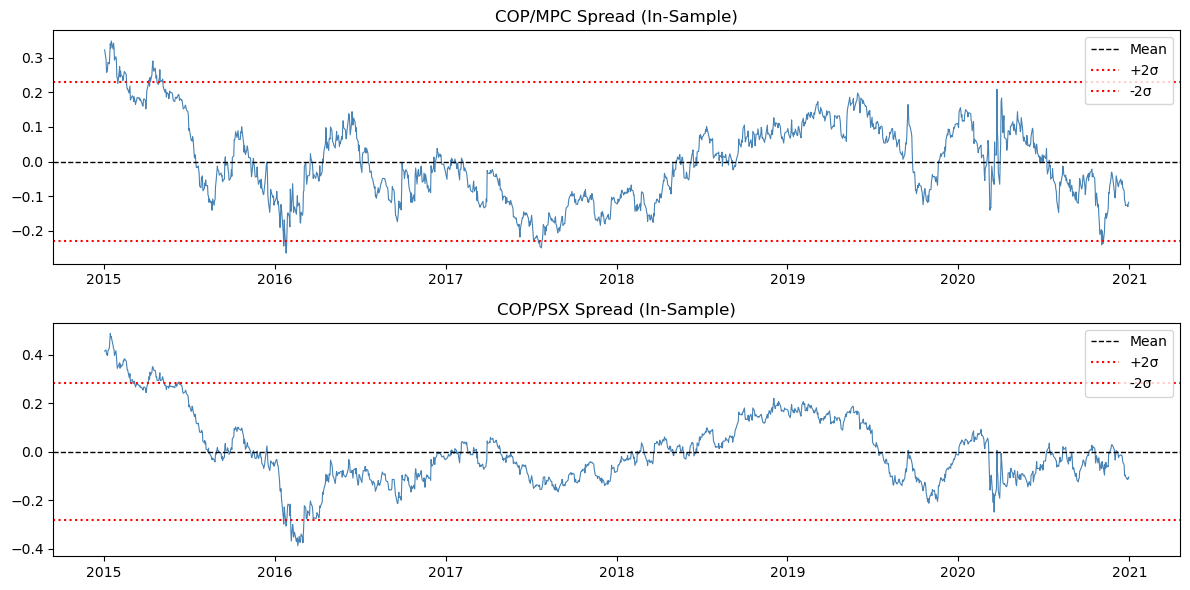

In [3]:
# We'll work with both cointegrated pairs
selected_pairs = [('COP', 'MPC'), ('COP', 'PSX')]

def estimate_hedge_ratio(s1, s2, log_px):
    """OLS regression to find beta: s1 = alpha + beta*s2"""
    y = log_px[s1]
    x = add_constant(log_px[s2])
    model = OLS(y, x).fit()
    beta = model.params[s2]
    alpha = model.params['const']
    return beta, alpha

def compute_spread(s1, s2, log_px, beta, alpha):
    """spread = s1 - beta*s2 - alpha"""
    return log_px[s1] - beta * log_px[s2] - alpha

# --- Estimate hedge ratios IN-SAMPLE ONLY ---
hedge_ratios = {}
for t1, t2 in selected_pairs:
    beta, alpha = estimate_hedge_ratio(t1, t2, log_IS)
    hedge_ratios[(t1, t2)] = (beta, alpha)
    print(f"{t1}/{t2} → beta={beta:.4f}, alpha={alpha:.4f}")

# --- Confirm spreads are stationary with ADF test ---
print("\nADF Test on IS spreads (p < 0.05 = stationary = good):\n")
for t1, t2 in selected_pairs:
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    adf_stat, adf_p, _, _, _, _ = adfuller(spread_IS)
    print(f"{t1}/{t2} → ADF stat={adf_stat:.4f}, p={adf_p:.4f} {'✓ Stationary' if adf_p < 0.05 else '✗ Not stationary'}")

# --- Plot the spreads ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for i, (t1, t2) in enumerate(selected_pairs):
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    axes[i].plot(spread_IS, color='steelblue', linewidth=0.8)
    axes[i].axhline(spread_IS.mean(), color='black', linestyle='--', linewidth=1, label='Mean')
    axes[i].axhline(spread_IS.mean() + 2*spread_IS.std(), color='red', linestyle=':', label='+2σ')
    axes[i].axhline(spread_IS.mean() - 2*spread_IS.std(), color='red', linestyle=':', label='-2σ')
    axes[i].set_title(f'{t1}/{t2} Spread (In-Sample)')
    axes[i].legend()
plt.tight_layout()
plt.show()

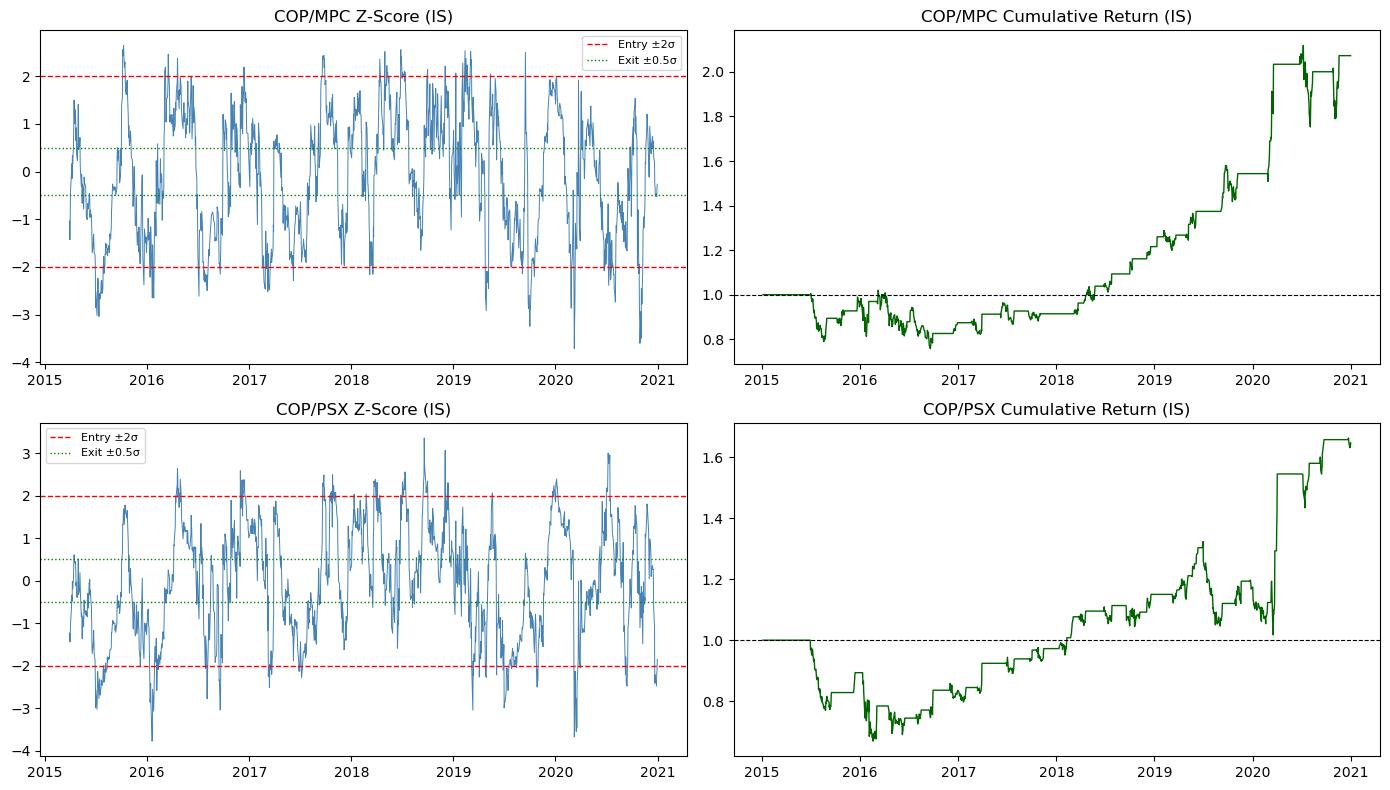


IN-SAMPLE PERFORMANCE

COP/MPC
  Ann. Return:   14.17%
  Ann. Vol:      20.12%
  Sharpe Ratio:  0.704
  Max Drawdown:  -25.68%
  Win Rate:      20.07%

COP/PSX
  Ann. Return:   10.32%
  Ann. Vol:      20.03%
  Sharpe Ratio:  0.515
  Max Drawdown:  -33.14%
  Win Rate:      20.53%


In [4]:
def zscore_rolling(spread, window=60):
    mean = spread.rolling(window).mean()
    std  = spread.rolling(window).std()
    return (spread - mean) / std

def build_positions(z, entry=2.0, exit=0.5):
    pos = pd.Series(0, index=z.index)
    for i in range(1, len(z)):
        prev = pos.iloc[i-1]
        zi   = z.iloc[i]
        if pd.isna(zi):
            pos.iloc[i] = 0
        elif prev == 0:
            if zi >  entry: pos.iloc[i] = -1   # spread too high → short it
            elif zi < -entry: pos.iloc[i] =  1  # spread too low  → long it
        elif prev ==  1 and zi >= -exit: pos.iloc[i] = 0   # close long
        elif prev == -1 and zi <=  exit: pos.iloc[i] = 0   # close short
        else: pos.iloc[i] = prev                            # hold
    return pos

def compute_returns(s1, s2, log_px, positions, beta):
    """Daily P&L: long s1, short beta*s2 (or reverse)"""
    r1 = log_px[s1].diff()
    r2 = log_px[s2].diff()
    spread_returns = r1 - beta * r2
    return positions.shift(1) * spread_returns   # shift(1) prevents look-ahead bias

# --- Build signals and compute IS returns ---
IS_metrics = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (t1, t2) in enumerate(selected_pairs):
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS   = compute_spread(t1, t2, log_IS, beta, alpha)
    z_IS        = zscore_rolling(spread_IS)
    pos_IS      = build_positions(z_IS)
    ret_IS      = compute_returns(t1, t2, log_IS, pos_IS, beta)

    # z-score plot
    axes[i][0].plot(z_IS, color='steelblue', linewidth=0.7)
    axes[i][0].axhline( 2.0, color='red',   linestyle='--', linewidth=1, label='Entry ±2σ')
    axes[i][0].axhline(-2.0, color='red',   linestyle='--', linewidth=1)
    axes[i][0].axhline( 0.5, color='green', linestyle=':',  linewidth=1, label='Exit ±0.5σ')
    axes[i][0].axhline(-0.5, color='green', linestyle=':',  linewidth=1)
    axes[i][0].set_title(f'{t1}/{t2} Z-Score (IS)')
    axes[i][0].legend(fontsize=8)

    # cumulative return plot
    cum_ret = (1 + ret_IS).cumprod()
    axes[i][1].plot(cum_ret, color='darkgreen', linewidth=1)
    axes[i][1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
    axes[i][1].set_title(f'{t1}/{t2} Cumulative Return (IS)')

    IS_metrics[(t1,t2)] = ret_IS

plt.tight_layout()
plt.show()

# --- Print IS performance summary ---
print("\nIN-SAMPLE PERFORMANCE\n" + "="*45)
for (t1,t2), ret in IS_metrics.items():
    ret = ret.dropna()
    sharpe   = (ret.mean() / ret.std()) * np.sqrt(252)
    ann_ret  = ret.mean() * 252
    ann_vol  = ret.std()  * np.sqrt(252)
    cum      = (1 + ret).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    win_rate = (ret > 0).mean()
    print(f"\n{t1}/{t2}")
    print(f"  Ann. Return:   {ann_ret:.2%}")
    print(f"  Ann. Vol:      {ann_vol:.2%}")
    print(f"  Sharpe Ratio:  {sharpe:.3f}")
    print(f"  Max Drawdown:  {max_dd:.2%}")
    print(f"  Win Rate:      {win_rate:.2%}")

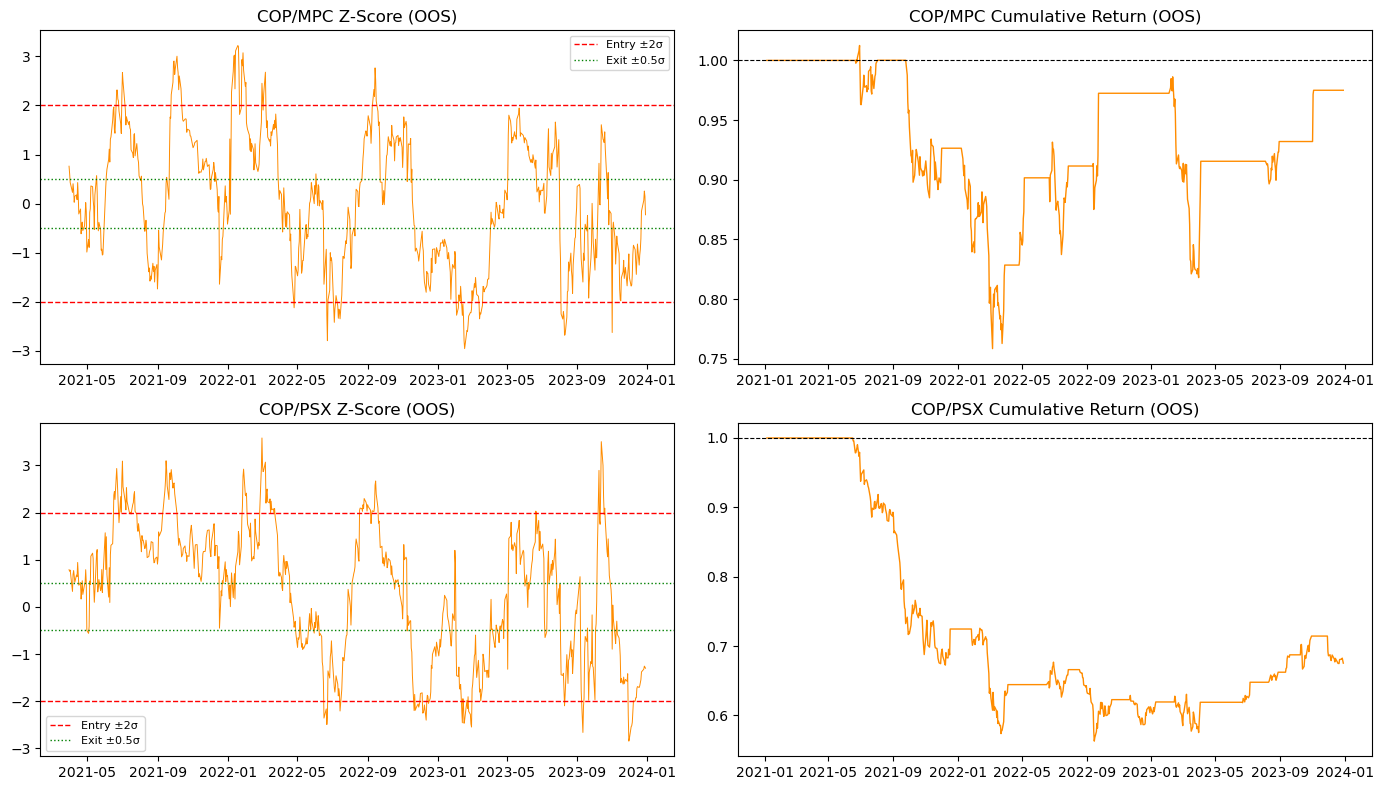


IS vs OOS PERFORMANCE COMPARISON
Metric                 COP/MPC IS  COP/MPC OOS   COP/PSX IS  COP/PSX OOS
------------------------------------------------------------
Sharpe                      0.704        0.013        0.515       -0.718
Ann. Return                14.17%        0.18%       10.32%      -11.80%
Ann. Vol                   20.12%       14.40%       20.03%       16.43%
Max Drawdown              -25.68%      -25.08%      -33.14%      -43.70%
Win Rate                   20.07%       15.03%       20.53%       23.14%


In [5]:
# ================================================================
# OUT-OF-SAMPLE TEST — PARAMETERS FROZEN FROM IN-SAMPLE
# We do NOT re-optimize anything from this point forward
# ================================================================

OOS_metrics = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (t1, t2) in enumerate(selected_pairs):
    # Frozen parameters from IS
    beta, alpha = hedge_ratios[(t1, t2)]
    
    spread_OOS = compute_spread(t1, t2, log_OOS, beta, alpha)
    z_OOS      = zscore_rolling(spread_OOS, window=60)
    pos_OOS    = build_positions(z_OOS, entry=2.0, exit=0.5)
    ret_OOS    = compute_returns(t1, t2, log_OOS, pos_OOS, beta)

    # z-score plot
    axes[i][0].plot(z_OOS, color='darkorange', linewidth=0.7)
    axes[i][0].axhline( 2.0, color='red',   linestyle='--', linewidth=1, label='Entry ±2σ')
    axes[i][0].axhline(-2.0, color='red',   linestyle='--', linewidth=1)
    axes[i][0].axhline( 0.5, color='green', linestyle=':',  linewidth=1, label='Exit ±0.5σ')
    axes[i][0].axhline(-0.5, color='green', linestyle=':',  linewidth=1)
    axes[i][0].set_title(f'{t1}/{t2} Z-Score (OOS)')
    axes[i][0].legend(fontsize=8)

    # cumulative return
    cum_ret = (1 + ret_OOS).cumprod()
    axes[i][1].plot(cum_ret, color='darkorange', linewidth=1)
    axes[i][1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
    axes[i][1].set_title(f'{t1}/{t2} Cumulative Return (OOS)')

    OOS_metrics[(t1,t2)] = ret_OOS

plt.tight_layout()
plt.show()

# --- Side-by-side IS vs OOS comparison table ---
print("\nIS vs OOS PERFORMANCE COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'COP/MPC IS':>12} {'COP/MPC OOS':>12} {'COP/PSX IS':>12} {'COP/PSX OOS':>12}")
print("-" * 60)

def metrics(ret):
    ret = ret.dropna()
    sharpe  = (ret.mean() / ret.std()) * np.sqrt(252)
    ann_ret = ret.mean() * 252
    ann_vol = ret.std()  * np.sqrt(252)
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    win     = (ret > 0).mean()
    return sharpe, ann_ret, ann_vol, max_dd, win

labels = ['Sharpe', 'Ann. Return', 'Ann. Vol', 'Max Drawdown', 'Win Rate']
IS_vals  = [metrics(IS_metrics[p])  for p in selected_pairs]
OOS_vals = [metrics(OOS_metrics[p]) for p in selected_pairs]

formats = ['.3f', '.2%', '.2%', '.2%', '.2%']
for j, label in enumerate(labels):
    row = f"{label:<20}"
    for k in range(2):
        row += f" {IS_vals[k][j]:>12{formats[j]}} {OOS_vals[k][j]:>12{formats[j]}}"
    print(row)
    

In [6]:
# ================================================
# TRANSACTION COSTS + SENSITIVITY ANALYSIS
# ================================================

# --- 1. Transaction Cost Impact on COP/MPC (the surviving pair) ---
cost_bps_list = [0, 5, 10, 20]   # basis points per trade

t1, t2 = 'COP', 'MPC'
beta, alpha = hedge_ratios[(t1, t2)]

print("TRANSACTION COST SENSITIVITY — COP/MPC")
print("=" * 55)
print(f"{'Cost (bps)':<15} {'IS Sharpe':>12} {'OOS Sharpe':>12} {'OOS Ann. Ret':>14}")
print("-" * 55)

for bps in cost_bps_list:
    cost = bps / 10000

    # IS
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    z_IS      = zscore_rolling(spread_IS)
    pos_IS    = build_positions(z_IS)
    ret_IS    = compute_returns(t1, t2, log_IS, pos_IS, beta)
    trades_IS = pos_IS.diff().abs()
    net_IS    = ret_IS - trades_IS * cost
    sh_IS     = (net_IS.mean() / net_IS.std()) * np.sqrt(252)

    # OOS
    spread_OOS = compute_spread(t1, t2, log_OOS, beta, alpha)
    z_OOS      = zscore_rolling(spread_OOS)
    pos_OOS    = build_positions(z_OOS)
    ret_OOS    = compute_returns(t1, t2, log_OOS, pos_OOS, beta)
    trades_OOS = pos_OOS.diff().abs()
    net_OOS    = ret_OOS - trades_OOS * cost
    sh_OOS     = (net_OOS.mean() / net_OOS.std()) * np.sqrt(252)
    ann_OOS    = net_OOS.mean() * 252

    print(f"{bps:<15} {sh_IS:>12.3f} {sh_OOS:>12.3f} {ann_OOS:>14.2%}")

# --- 2. Entry Threshold Sensitivity (IS only — never tune on OOS) ---
print("\n\nENTRY THRESHOLD SENSITIVITY — COP/MPC (In-Sample)")
print("=" * 45)
print(f"{'Entry σ':<12} {'Exit σ':<12} {'IS Sharpe':>12}")
print("-" * 45)

spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
z_IS      = zscore_rolling(spread_IS)

for entry in [1.5, 2.0, 2.5]:
    for exit_t in [0.25, 0.5, 0.75]:
        pos  = build_positions(z_IS, entry=entry, exit=exit_t)
        ret  = compute_returns(t1, t2, log_IS, pos, beta)
        sh   = (ret.mean() / ret.std()) * np.sqrt(252)
        print(f"{entry:<12} {exit_t:<12} {sh:>12.3f}")

TRANSACTION COST SENSITIVITY — COP/MPC
Cost (bps)         IS Sharpe   OOS Sharpe   OOS Ann. Ret
-------------------------------------------------------
0                      0.704        0.013          0.18%
5                      0.684       -0.008         -0.12%
10                     0.664       -0.029         -0.42%
20                     0.623       -0.072         -1.03%


ENTRY THRESHOLD SENSITIVITY — COP/MPC (In-Sample)
Entry σ      Exit σ          IS Sharpe
---------------------------------------------
1.5          0.25                0.590
1.5          0.5                 0.703
1.5          0.75                0.952
2.0          0.25                0.534
2.0          0.5                 0.704
2.0          0.75                0.967
2.5          0.25                0.657
2.5          0.5                 0.808
2.5          0.75                0.691


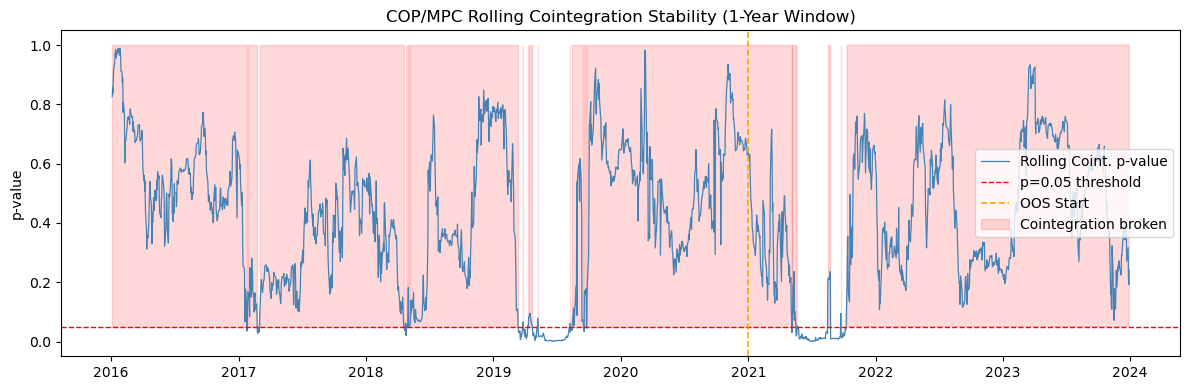

Cointegration held:  206/2012 days (10.2%)
Cointegration broke: 1806/2012 days (89.8%)

Post-2021 breakdown rate: 87.5%


In [7]:
# ================================================
# COINTEGRATION STABILITY ANALYSIS
# Shows WHERE and WHEN the relationship broke down
# ================================================
from statsmodels.tsa.stattools import coint

t1, t2 = 'COP', 'MPC'
full_log = np.log(prices)

window  = 252   # rolling 1-year window
dates   = full_log.index[window:]
pvalues = []

for i in range(len(dates)):
    window_data = full_log.iloc[i : i + window]
    _, pval, _  = coint(window_data[t1], window_data[t2])
    pvalues.append(pval)

pval_series = pd.Series(pvalues, index=dates)

plt.figure(figsize=(12, 4))
plt.plot(pval_series, color='steelblue', linewidth=0.9, label='Rolling Coint. p-value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p=0.05 threshold')
plt.axvline(pd.Timestamp('2021-01-01'), color='orange', 
            linestyle='--', linewidth=1.2, label='OOS Start')
plt.fill_between(pval_series.index, 0.05, 1.0, 
                 where=pval_series > 0.05, alpha=0.15, color='red', 
                 label='Cointegration broken')
plt.title('COP/MPC Rolling Cointegration Stability (1-Year Window)')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()
plt.show()

# Summary
broken = (pval_series > 0.05).sum()
total  = len(pval_series)
print(f"Cointegration held:  {total-broken}/{total} days ({(total-broken)/total:.1%})")
print(f"Cointegration broke: {broken}/{total} days ({broken/total:.1%})")
print(f"\nPost-2021 breakdown rate: ", end="")
post2021 = pval_series[pval_series.index >= '2021-01-01']
print(f"{(post2021 > 0.05).mean():.1%}")

In [8]:
pip install pykalman

Note: you may need to restart the kernel to use updated packages.


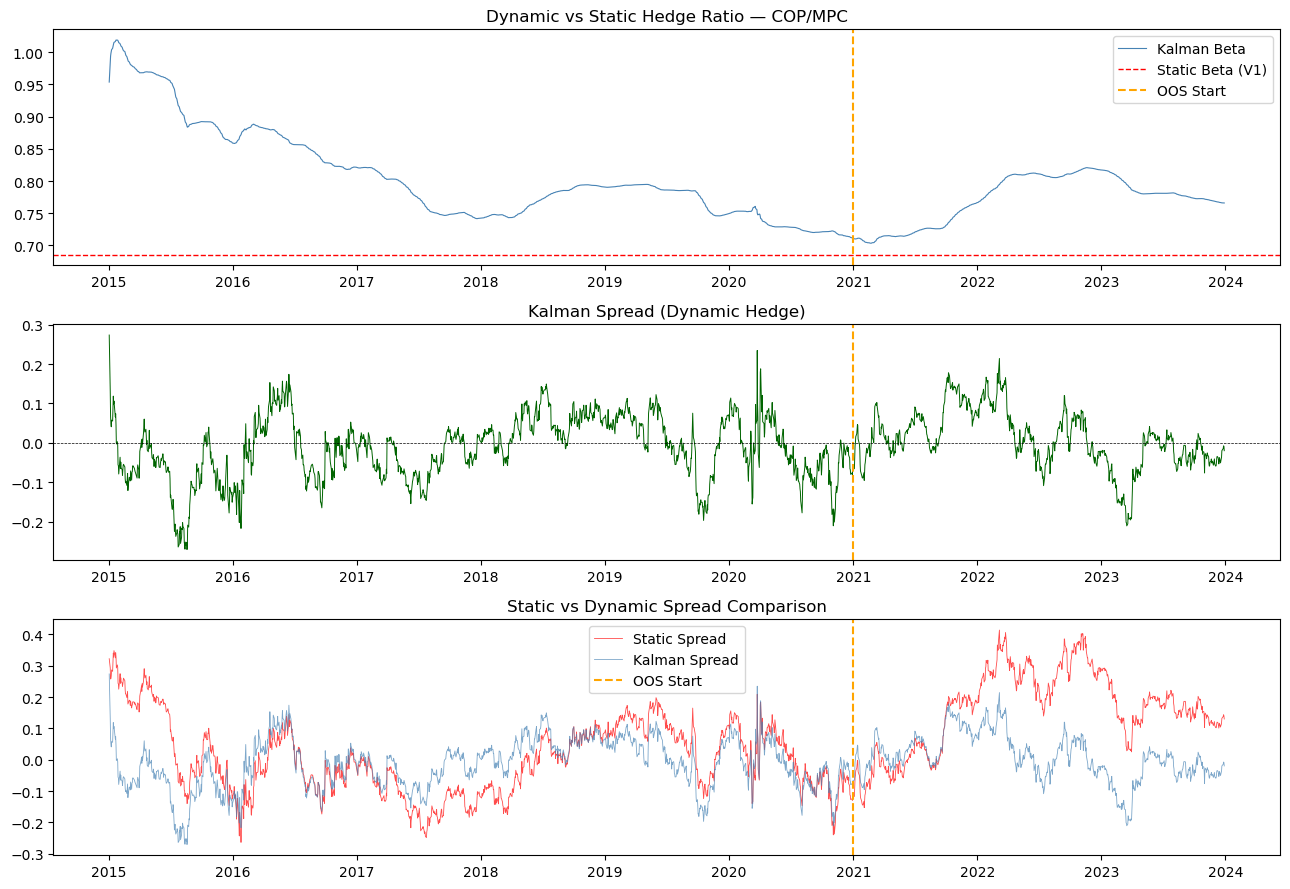

In [9]:
from pykalman import KalmanFilter
import numpy as np

def kalman_hedge_ratio(x, y):
    """
    Estimates time-varying hedge ratio using Kalman Filter.
    Returns: arrays of dynamic beta, alpha, and spread at each timestep
    """
    # State: [beta, alpha] — both evolve as random walks
    n = len(x)
    
    # Initialize Kalman Filter
    delta = 1e-5   # state transition noise — controls how fast beta can change
    
    # We'll implement the filter manually for full control
    # State vector: [beta, alpha]
    beta  = np.zeros(n)
    alpha = np.zeros(n)
    spread = np.zeros(n)
    
    # Initial state covariance
    P = np.eye(2)
    
    # State transition matrix (random walk)
    F = np.eye(2)
    
    # State noise
    Q = delta / (1 - delta) * np.eye(2)
    
    # Observation noise
    R = np.array([[1.0]])
    
    # Initial state estimate
    theta = np.zeros(2)  # [beta, alpha]
    
    for t in range(n):
        # Observation matrix: H = [x_t, 1]
        H = np.array([[x.iloc[t], 1.0]])
        
        # Predict
        theta_pred = F @ theta
        P_pred     = F @ P @ F.T + Q
        
        # Innovation
        y_pred = H @ theta_pred
        innov  = y.iloc[t] - y_pred[0]
        
        # Kalman gain
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T / S[0, 0]
        
        # Update
        theta = theta_pred + K.flatten() * innov
        P     = (np.eye(2) - K @ H) @ P_pred
        
        beta[t]   = theta[0]
        alpha[t]  = theta[1]
        spread[t] = y.iloc[t] - theta[0] * x.iloc[t] - theta[1]
    
    return beta, alpha, spread

# Apply to your full price series (IS + OOS together, filter is causal)
t1, t2 = 'COP', 'MPC'
x = np.log(prices[t2])
y = np.log(prices[t1])

beta_kf, alpha_kf, spread_kf = kalman_hedge_ratio(x, y)

# Plot dynamic hedge ratio vs static
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(prices.index, beta_kf, color='steelblue', linewidth=0.8, label='Kalman Beta')
axes[0].axhline(0.6858, color='red', linestyle='--', linewidth=1, label='Static Beta (V1)')
axes[0].axvline(pd.Timestamp('2021-01-01'), color='orange', linestyle='--', label='OOS Start')
axes[0].set_title('Dynamic vs Static Hedge Ratio — COP/MPC')
axes[0].legend()

spread_series = pd.Series(spread_kf, index=prices.index)
axes[1].plot(spread_series, color='darkgreen', linewidth=0.7)
axes[1].axvline(pd.Timestamp('2021-01-01'), color='orange', linestyle='--')
axes[1].set_title('Kalman Spread (Dynamic Hedge)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)

# Compare static vs dynamic spread
static_spread = np.log(prices[t1]) - 0.6858 * np.log(prices[t2]) - 1.1584
axes[2].plot(pd.Series(static_spread.values, index=prices.index), 
             color='red', linewidth=0.6, alpha=0.7, label='Static Spread')
axes[2].plot(spread_series, color='steelblue', linewidth=0.6, alpha=0.7, label='Kalman Spread')
axes[2].axvline(pd.Timestamp('2021-01-01'), color='orange', linestyle='--', label='OOS Start')
axes[2].legend()
axes[2].set_title('Static vs Dynamic Spread Comparison')

plt.tight_layout()
plt.show()

V2 KALMAN — IS vs OOS PERFORMANCE
Metric                       IS          OOS
--------------------------------------------------
Sharpe                    1.023       -0.111
Return                   21.01%       -1.69%
Vol                      20.54%       15.17%
MaxDD                   -25.54%      -28.49%
WinRate                  17.75%       21.81%

OOS SHARPE COMPARISON
  V1 Static Hedge:   0.013
  V2 Kalman Hedge:   -0.111


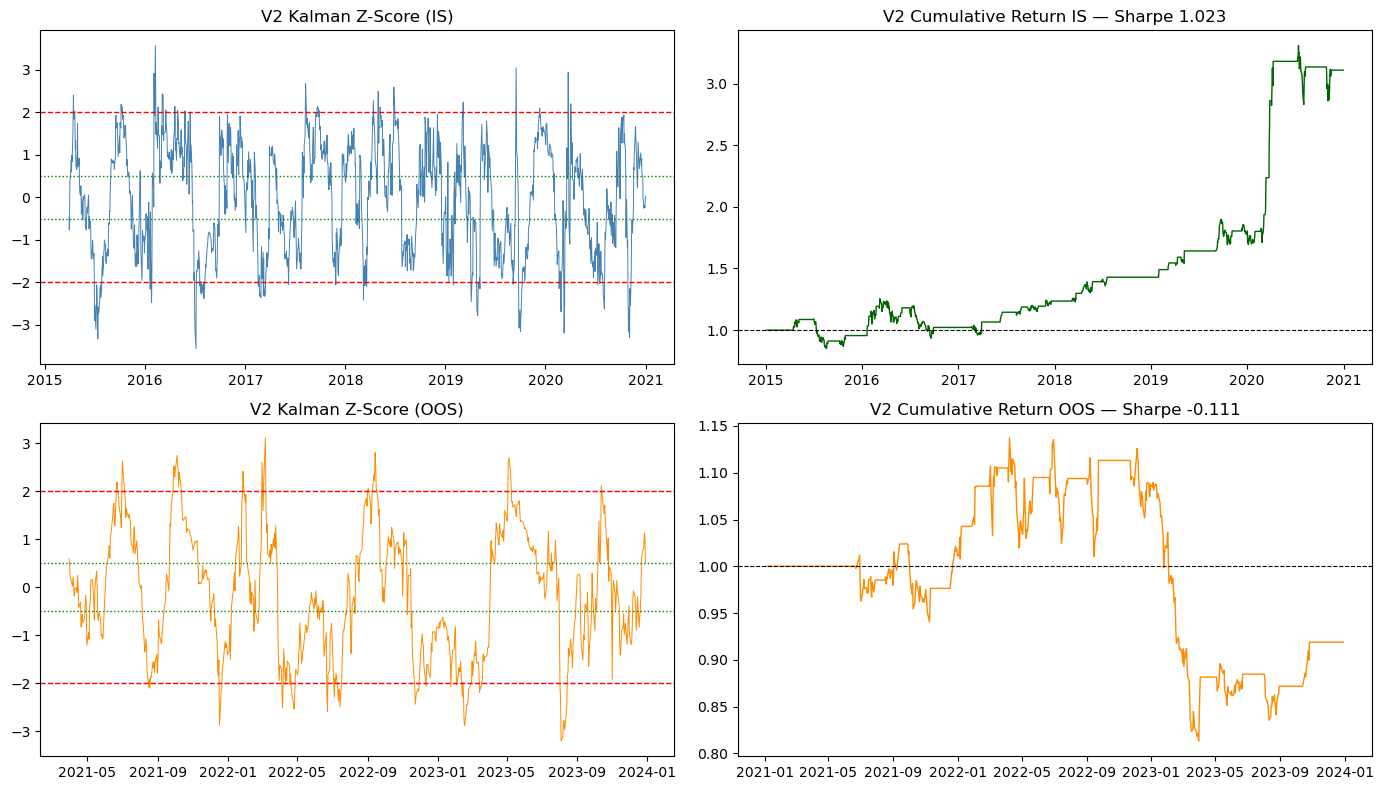

In [10]:
# ================================================
# V2 BACKTEST — KALMAN DYNAMIC HEDGE RATIO
# ================================================

def zscore_rolling(series, window=60):
    m = series.rolling(window).mean()
    s = series.rolling(window).std()
    return (series - m) / s

def build_positions(z, entry=2.0, exit=0.5):
    pos = pd.Series(0, index=z.index)
    for i in range(1, len(z)):
        prev = pos.iloc[i-1]
        zi   = z.iloc[i]
        if pd.isna(zi):
            pos.iloc[i] = 0
        elif prev == 0:
            if zi >  entry: pos.iloc[i] = -1
            elif zi < -entry: pos.iloc[i] =  1
        elif prev ==  1 and zi >= -exit: pos.iloc[i] = 0
        elif prev == -1 and zi <=  exit: pos.iloc[i] = 0
        else: pos.iloc[i] = prev
    return pos

# Split Kalman outputs into IS and OOS
split_date = '2020-12-31'
is_mask    = prices.index <= split_date
oos_mask   = prices.index >= '2021-01-01'

# Build spread series from Kalman
spread_full = pd.Series(spread_kf, index=prices.index)
beta_full   = pd.Series(beta_kf,   index=prices.index)

spread_IS_kf  = spread_full[is_mask]
spread_OOS_kf = spread_full[oos_mask]
beta_IS_kf    = beta_full[is_mask]
beta_OOS_kf   = beta_full[oos_mask]

# --- Z-scores ---
z_IS_kf  = zscore_rolling(spread_IS_kf)
z_OOS_kf = zscore_rolling(spread_OOS_kf)

# --- Positions ---
pos_IS_kf  = build_positions(z_IS_kf)
pos_OOS_kf = build_positions(z_OOS_kf)

# --- Returns (using dynamic beta each day) ---
r_cop = np.log(prices['COP']).diff()
r_mpc = np.log(prices['MPC']).diff()

# Daily spread return = r_COP - beta_t * r_MPC
spread_ret_full = r_cop - beta_full * r_mpc

ret_IS_kf  = (pos_IS_kf.shift(1)  * spread_ret_full[is_mask]).dropna()
ret_OOS_kf = (pos_OOS_kf.shift(1) * spread_ret_full[oos_mask]).dropna()

def metrics(ret):
    ret = ret.dropna()
    sharpe  = (ret.mean() / ret.std()) * np.sqrt(252)
    ann_ret = ret.mean() * 252
    ann_vol = ret.std()  * np.sqrt(252)
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    win     = (ret > 0).mean()
    return dict(Sharpe=sharpe, Return=ann_ret, Vol=ann_vol,
                MaxDD=max_dd, WinRate=win)

m_IS  = metrics(ret_IS_kf)
m_OOS = metrics(ret_OOS_kf)

# --- Print comparison ---
print("V2 KALMAN — IS vs OOS PERFORMANCE")
print("=" * 50)
print(f"{'Metric':<18} {'IS':>12} {'OOS':>12}")
print("-" * 50)
for k in m_IS:
    fmt = '.3f' if k == 'Sharpe' else '.2%'
    print(f"{k:<18} {m_IS[k]:>12{fmt}} {m_OOS[k]:>12{fmt}}")

# --- Also print V1 vs V2 OOS comparison ---
print("\nOOS SHARPE COMPARISON")
print("=" * 35)
print(f"  V1 Static Hedge:   0.013")
print(f"  V2 Kalman Hedge:   {m_OOS['Sharpe']:.3f}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# IS z-score
axes[0][0].plot(z_IS_kf, color='steelblue', linewidth=0.7)
axes[0][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[0][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
axes[0][0].axhline( 0.5, color='green', linestyle=':', linewidth=1)
axes[0][0].axhline(-0.5, color='green', linestyle=':', linewidth=1)
axes[0][0].set_title('V2 Kalman Z-Score (IS)')

# IS cumulative return
cum_IS = (1 + ret_IS_kf).cumprod()
axes[0][1].plot(cum_IS, color='darkgreen', linewidth=1)
axes[0][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[0][1].set_title(f'V2 Cumulative Return IS — Sharpe {m_IS["Sharpe"]:.3f}')

# OOS z-score
axes[1][0].plot(z_OOS_kf, color='darkorange', linewidth=0.7)
axes[1][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[1][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
axes[1][0].axhline( 0.5, color='green', linestyle=':', linewidth=1)
axes[1][0].axhline(-0.5, color='green', linestyle=':', linewidth=1)
axes[1][0].set_title('V2 Kalman Z-Score (OOS)')

# OOS cumulative return
cum_OOS = (1 + ret_OOS_kf).cumprod()
axes[1][1].plot(cum_OOS, color='darkorange', linewidth=1)
axes[1][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[1][1].set_title(f'V2 Cumulative Return OOS — Sharpe {m_OOS["Sharpe"]:.3f}')

plt.tight_layout()
plt.show()

IS final beta:  0.7106
IS final alpha: 1.0185
OOS beta range: 0.7034 to 0.8208

V3 CAUSAL KALMAN — IS vs OOS PERFORMANCE
Metric                       IS          OOS
--------------------------------------------------
Sharpe                    1.023       -0.111
Return                   21.01%       -1.69%
Vol                      20.54%       15.17%
MaxDD                   -25.54%      -28.49%
WinRate                  17.75%       21.81%

OOS SHARPE PROGRESSION
  V1 Static Hedge:        0.013
  V2 Kalman (leaky):     -0.111
  V3 Kalman (causal):    -0.111


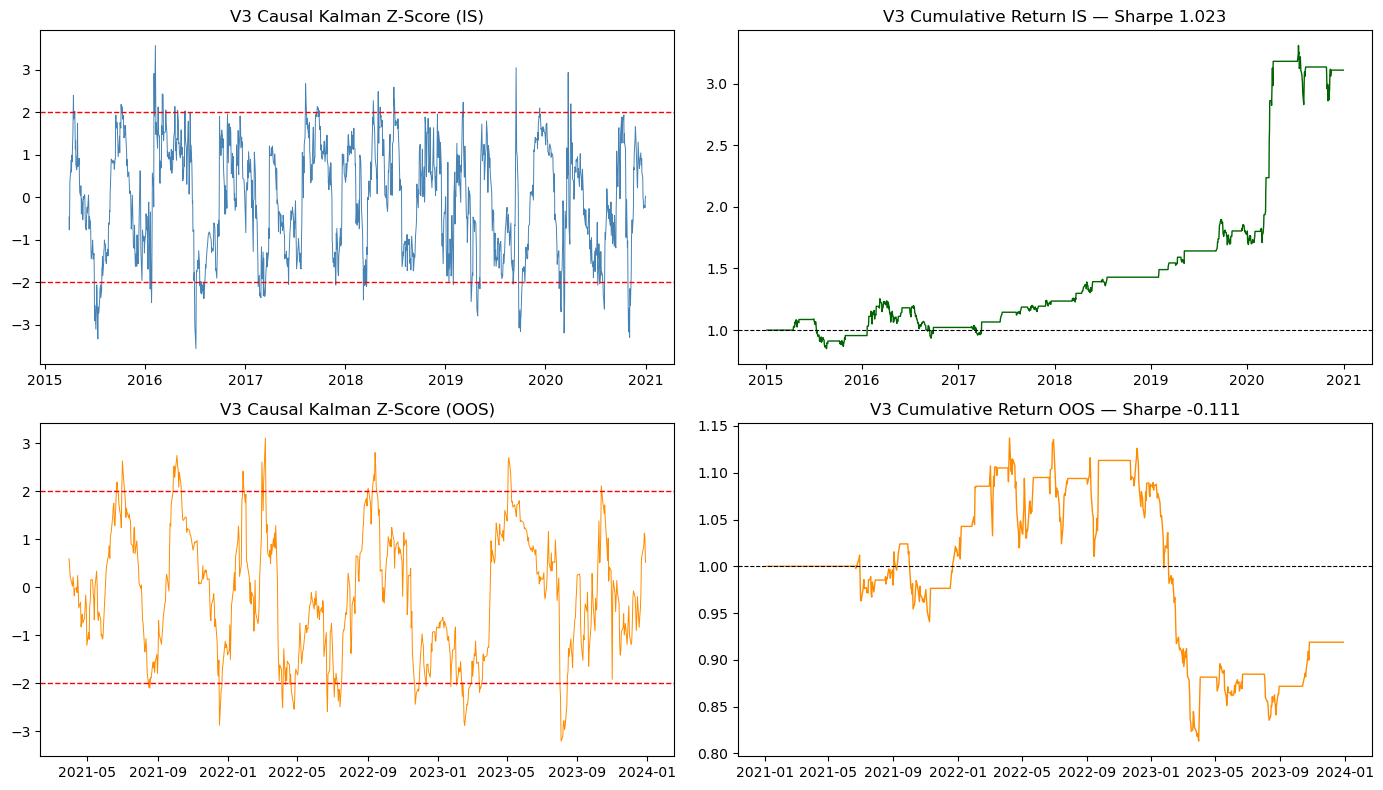

In [11]:
# ================================================
# V3 — CAUSALLY CORRECT KALMAN IMPLEMENTATION
# Train filter on IS only, apply forward to OOS
# ================================================

t1, t2 = 'COP', 'MPC'
x_full = np.log(prices[t2])
y_full = np.log(prices[t1])

x_IS = x_full[is_mask]
y_IS = y_full[is_mask]
x_OOS = x_full[oos_mask]
y_OOS = y_full[oos_mask]

def kalman_filter_causal(x, y, delta=1e-5, 
                          theta_init=None, P_init=None):
    """
    Runs Kalman filter causally through a price series.
    Returns beta, alpha, spread at each timestep.
    Optionally starts from a provided state (for OOS continuation).
    """
    n = len(x)
    beta_arr  = np.zeros(n)
    alpha_arr = np.zeros(n)
    spread_arr = np.zeros(n)

    F = np.eye(2)
    Q = delta / (1 - delta) * np.eye(2)
    R = np.array([[1.0]])

    # Initialize state
    theta = theta_init if theta_init is not None else np.zeros(2)
    P     = P_init     if P_init     is not None else np.eye(2)

    for t in range(n):
        H = np.array([[x.iloc[t], 1.0]])

        # Predict
        theta_pred = F @ theta
        P_pred     = F @ P @ F.T + Q

        # Innovation
        innov = y.iloc[t] - (H @ theta_pred)[0]

        # Kalman gain
        S = (H @ P_pred @ H.T + R)[0, 0]
        K = (P_pred @ H.T) / S

        # Update
        theta = theta_pred + K.flatten() * innov
        P     = (np.eye(2) - K @ H) @ P_pred

        beta_arr[t]   = theta[0]
        alpha_arr[t]  = theta[1]
        spread_arr[t] = y.iloc[t] - theta[0]*x.iloc[t] - theta[1]

    # Return final state for continuation
    return beta_arr, alpha_arr, spread_arr, theta, P

# --- Step 1: Run filter on IS data only ---
beta_IS, alpha_IS, spread_IS_v3, theta_final, P_final = \
    kalman_filter_causal(x_IS, y_IS)

# --- Step 2: Continue filter into OOS from IS final state ---
# This is the key fix — OOS filter starts exactly where IS left off
beta_OOS, alpha_OOS, spread_OOS_v3, _, _ = \
    kalman_filter_causal(x_OOS, y_OOS, 
                         theta_init=theta_final, 
                         P_init=P_final)

print(f"IS final beta:  {theta_final[0]:.4f}")
print(f"IS final alpha: {theta_final[1]:.4f}")
print(f"OOS beta range: {beta_OOS.min():.4f} to {beta_OOS.max():.4f}")

# --- Build series ---
spread_IS_s  = pd.Series(spread_IS_v3,  index=x_IS.index)
spread_OOS_s = pd.Series(spread_OOS_v3, index=x_OOS.index)
beta_IS_s    = pd.Series(beta_IS,       index=x_IS.index)
beta_OOS_s   = pd.Series(beta_OOS,      index=x_OOS.index)

# --- Z-scores and positions ---
z_IS_v3  = zscore_rolling(spread_IS_s)
z_OOS_v3 = zscore_rolling(spread_OOS_s)
pos_IS_v3  = build_positions(z_IS_v3)
pos_OOS_v3 = build_positions(z_OOS_v3)

# --- Returns using daily dynamic beta ---
r1 = np.log(prices[t1]).diff()
r2 = np.log(prices[t2]).diff()

spread_ret_IS  = (r1 - beta_IS_s  * r2)[is_mask]
spread_ret_OOS = (r1 - beta_OOS_s * r2)[oos_mask]

ret_IS_v3  = (pos_IS_v3.shift(1)  * spread_ret_IS).dropna()
ret_OOS_v3 = (pos_OOS_v3.shift(1) * spread_ret_OOS).dropna()

# --- Metrics ---
m_IS_v3  = metrics(ret_IS_v3)
m_OOS_v3 = metrics(ret_OOS_v3)

print("\nV3 CAUSAL KALMAN — IS vs OOS PERFORMANCE")
print("=" * 50)
print(f"{'Metric':<18} {'IS':>12} {'OOS':>12}")
print("-" * 50)
for k in m_IS_v3:
    fmt = '.3f' if k == 'Sharpe' else '.2%'
    print(f"{k:<18} {m_IS_v3[k]:>12{fmt}} {m_OOS_v3[k]:>12{fmt}}")

print("\nOOS SHARPE PROGRESSION")
print("=" * 35)
print(f"  V1 Static Hedge:        0.013")
print(f"  V2 Kalman (leaky):     -0.111")
print(f"  V3 Kalman (causal):    {m_OOS_v3['Sharpe']:.3f}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

cum_IS_v3  = (1 + ret_IS_v3).cumprod()
cum_OOS_v3 = (1 + ret_OOS_v3).cumprod()

axes[0][0].plot(z_IS_v3,  color='steelblue',  linewidth=0.7)
axes[0][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[0][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
axes[0][0].set_title('V3 Causal Kalman Z-Score (IS)')

axes[0][1].plot(cum_IS_v3, color='darkgreen', linewidth=1)
axes[0][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[0][1].set_title(f'V3 Cumulative Return IS — Sharpe {m_IS_v3["Sharpe"]:.3f}')

axes[1][0].plot(z_OOS_v3, color='darkorange', linewidth=0.7)
axes[1][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[1][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
axes[1][0].set_title('V3 Causal Kalman Z-Score (OOS)')

axes[1][1].plot(cum_OOS_v3, color='darkorange', linewidth=1)
axes[1][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[1][1].set_title(f'V3 Cumulative Return OOS — Sharpe {m_OOS_v3["Sharpe"]:.3f}')

plt.tight_layout()
plt.show()

Low-vol state:  0  (var=0.000283)  ← TRADE
High-vol state: 1 (var=0.003059)  ← NO TRADE

IS mean returns by state:
  State 0: mean=-0.00062, vol=0.01705, n=1423
  State 1: mean=0.00616, vol=0.06160, n=87

IS  — % time in trade regime: 94.2%
OOS — % time in trade regime: 99.6%

Metric                  V1 IS     V1 OOS      V4 IS     V4 OOS
-----------------------------------------------------------------
Sharpe                  0.704      0.013      0.452     -0.111
Return                 14.17%      0.18%      7.47%     -1.69%
Vol                    20.12%     14.40%     16.52%     15.17%
MaxDD                 -25.68%    -25.08%    -30.55%    -28.49%
WinRate                20.07%     15.03%     16.03%     21.81%


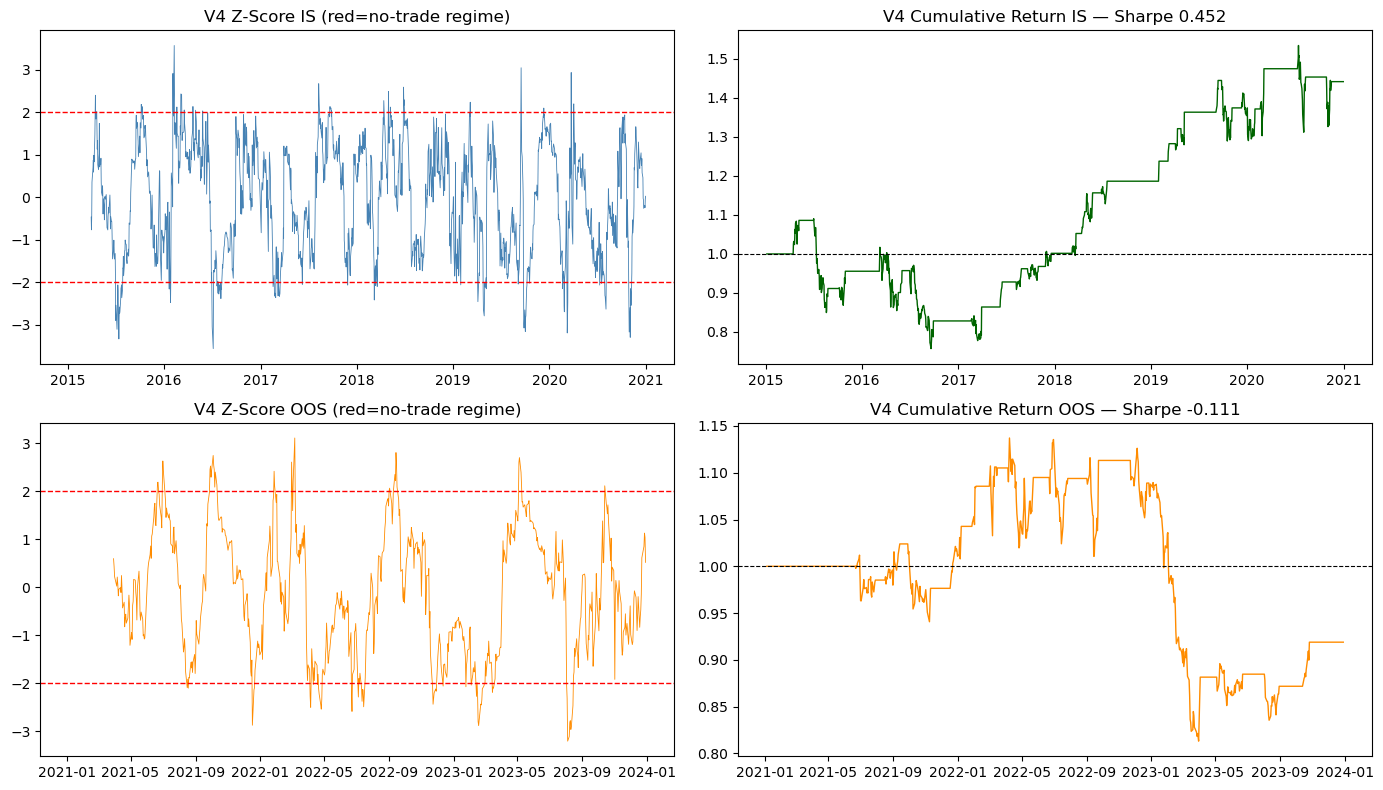

In [12]:
# ================================================
# V4 — HMM REGIME FILTER ON TOP OF CAUSAL KALMAN
# Only trade during detected mean-reversion regime
# ================================================
from hmmlearn.hmm import GaussianHMM

# --- Fit HMM on IS spread returns only ---
spread_ret_IS_series = spread_IS_s.diff().dropna()

X_train = spread_ret_IS_series.values.reshape(-1, 1)

hmm = GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)
hmm.fit(X_train)

# Identify low-vol (mean-reverting) state
vars_   = [hmm.covars_[i][0][0] for i in range(2)]
lo_state = int(np.argmin(vars_))
hi_state = 1 - lo_state

print(f"Low-vol state:  {lo_state}  (var={vars_[lo_state]:.6f})  ← TRADE")
print(f"High-vol state: {hi_state} (var={vars_[hi_state]:.6f})  ← NO TRADE")
print(f"\nIS mean returns by state:")
for s in range(2):
    mask = hmm.predict(X_train) == s
    print(f"  State {s}: mean={X_train[mask].mean():.5f}, "
          f"vol={X_train[mask].std():.5f}, "
          f"n={mask.sum()}")

# --- Apply HMM to IS ---
regimes_IS  = hmm.predict(X_train)
regime_IS_s = pd.Series(regimes_IS, index=spread_ret_IS_series.index)

# --- Apply HMM to OOS (using IS-trained model) ---
spread_ret_OOS_series = spread_OOS_s.diff().dropna()
X_test = spread_ret_OOS_series.values.reshape(-1, 1)
regimes_OOS  = hmm.predict(X_test)
regime_OOS_s = pd.Series(regimes_OOS, index=spread_ret_OOS_series.index)

print(f"\nIS  — % time in trade regime: "
      f"{(regime_IS_s==lo_state).mean():.1%}")
print(f"OOS — % time in trade regime: "
      f"{(regime_OOS_s==lo_state).mean():.1%}")

# --- Build regime-filtered positions ---
def build_positions_regime_filtered(z, regime, lo_state, 
                                     entry=2.0, exit=0.5):
    """Only enter positions when in low-vol mean-reverting regime."""
    pos = pd.Series(0, index=z.index)
    for i in range(1, len(z)):
        prev = pos.iloc[i-1]
        zi   = z.iloc[i]
        # Get regime for this date (if available)
        date = z.index[i]
        in_trade_regime = (regime.get(date, hi_state) == lo_state)

        if pd.isna(zi):
            pos.iloc[i] = 0
        elif prev != 0:
            # Already in position — exit normally regardless of regime
            if prev ==  1 and zi >= -exit: pos.iloc[i] = 0
            elif prev == -1 and zi <=  exit: pos.iloc[i] = 0
            else: pos.iloc[i] = prev
        elif in_trade_regime:
            # Only enter new positions in mean-reversion regime
            if zi >  entry: pos.iloc[i] = -1
            elif zi < -entry: pos.iloc[i] =  1
        # else: stay flat
    return pos

pos_IS_v4  = build_positions_regime_filtered(
    z_IS_v3, regime_IS_s, lo_state)
pos_OOS_v4 = build_positions_regime_filtered(
    z_OOS_v3, regime_OOS_s, lo_state)

# --- Returns ---
ret_IS_v4  = (pos_IS_v4.shift(1)  * spread_ret_IS).dropna()
ret_OOS_v4 = (pos_OOS_v4.shift(1) * spread_ret_OOS).dropna()

m_IS_v4  = metrics(ret_IS_v4)
m_OOS_v4 = metrics(ret_OOS_v4)

# --- Full comparison table ---
print("\n" + "="*65)
print(f"{'Metric':<18} {'V1 IS':>10} {'V1 OOS':>10} "
      f"{'V4 IS':>10} {'V4 OOS':>10}")
print("-"*65)
v1_IS  = {'Sharpe':0.704,'Return':0.1417,'Vol':0.2012,
           'MaxDD':-0.2568,'WinRate':0.2007}
v1_OOS = {'Sharpe':0.013,'Return':0.0018,'Vol':0.1440,
           'MaxDD':-0.2508,'WinRate':0.1503}
for k in m_IS_v4:
    fmt = '.3f' if k=='Sharpe' else '.2%'
    print(f"{k:<18} {v1_IS[k]:>10{fmt}} {v1_OOS[k]:>10{fmt}} "
          f"{m_IS_v4[k]:>10{fmt}} {m_OOS_v4[k]:>10{fmt}}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cum_IS_v4  = (1 + ret_IS_v4).cumprod()
cum_OOS_v4 = (1 + ret_OOS_v4).cumprod()

# IS with regime shading
axes[0][0].plot(z_IS_v3, color='steelblue', linewidth=0.6)
axes[0][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[0][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
for date, reg in regime_IS_s.items():
    if reg == hi_state:
        axes[0][0].axvspan(date, date, alpha=0.3, color='red', linewidth=0)
axes[0][0].set_title('V4 Z-Score IS (red=no-trade regime)')

axes[0][1].plot(cum_IS_v4, color='darkgreen', linewidth=1)
axes[0][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[0][1].set_title(f'V4 Cumulative Return IS — Sharpe {m_IS_v4["Sharpe"]:.3f}')

# OOS with regime shading
axes[1][0].plot(z_OOS_v3, color='darkorange', linewidth=0.6)
axes[1][0].axhline( 2, color='red',   linestyle='--', linewidth=1)
axes[1][0].axhline(-2, color='red',   linestyle='--', linewidth=1)
for date, reg in regime_OOS_s.items():
    if reg == hi_state:
        axes[1][0].axvspan(date, date, alpha=0.3, color='red', linewidth=0)
axes[1][0].set_title('V4 Z-Score OOS (red=no-trade regime)')

axes[1][1].plot(cum_OOS_v4, color='darkorange', linewidth=1)
axes[1][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[1][1].set_title(f'V4 Cumulative Return OOS — Sharpe {m_OOS_v4["Sharpe"]:.3f}')

plt.tight_layout()
plt.show()

Computing rolling cointegration p-values... (~30 seconds)
IS  — % time cointegration active: 18.2%
OOS — % time cointegration active: 24.6%


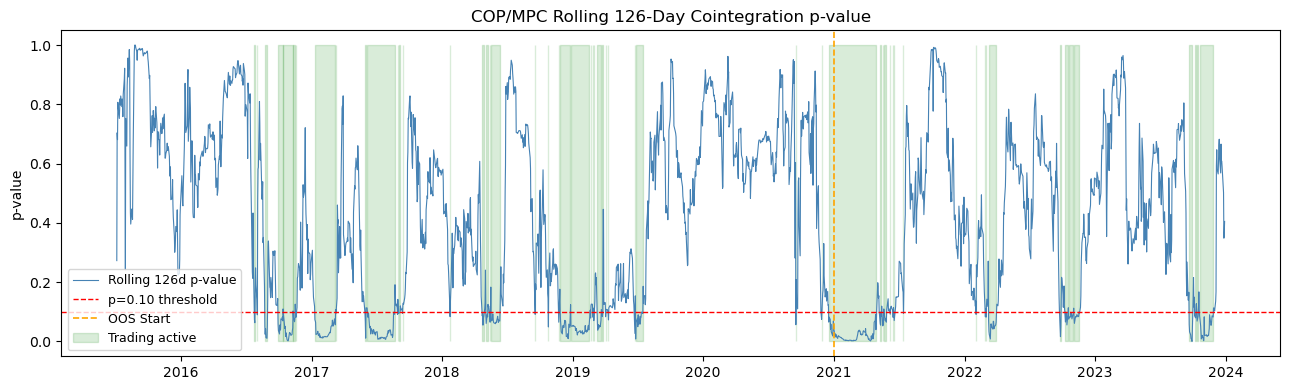


FULL VERSION COMPARISON
Metric                  V1 IS     V1 OOS      V3 IS     V3 OOS      V5 IS     V5 OOS
------------------------------------------------------------------------
Sharpe                  0.704      0.013      1.023     -0.111      0.423      0.465
Return                 14.17%      0.18%     21.01%     -1.69%      3.23%      2.15%
Vol                    20.12%     14.40%     20.54%     15.17%      7.64%      4.62%
MaxDD                 -25.68%    -25.08%    -25.54%    -28.49%    -14.36%     -6.74%
WinRate                20.07%     15.03%     17.75%     21.81%      3.84%      1.73%


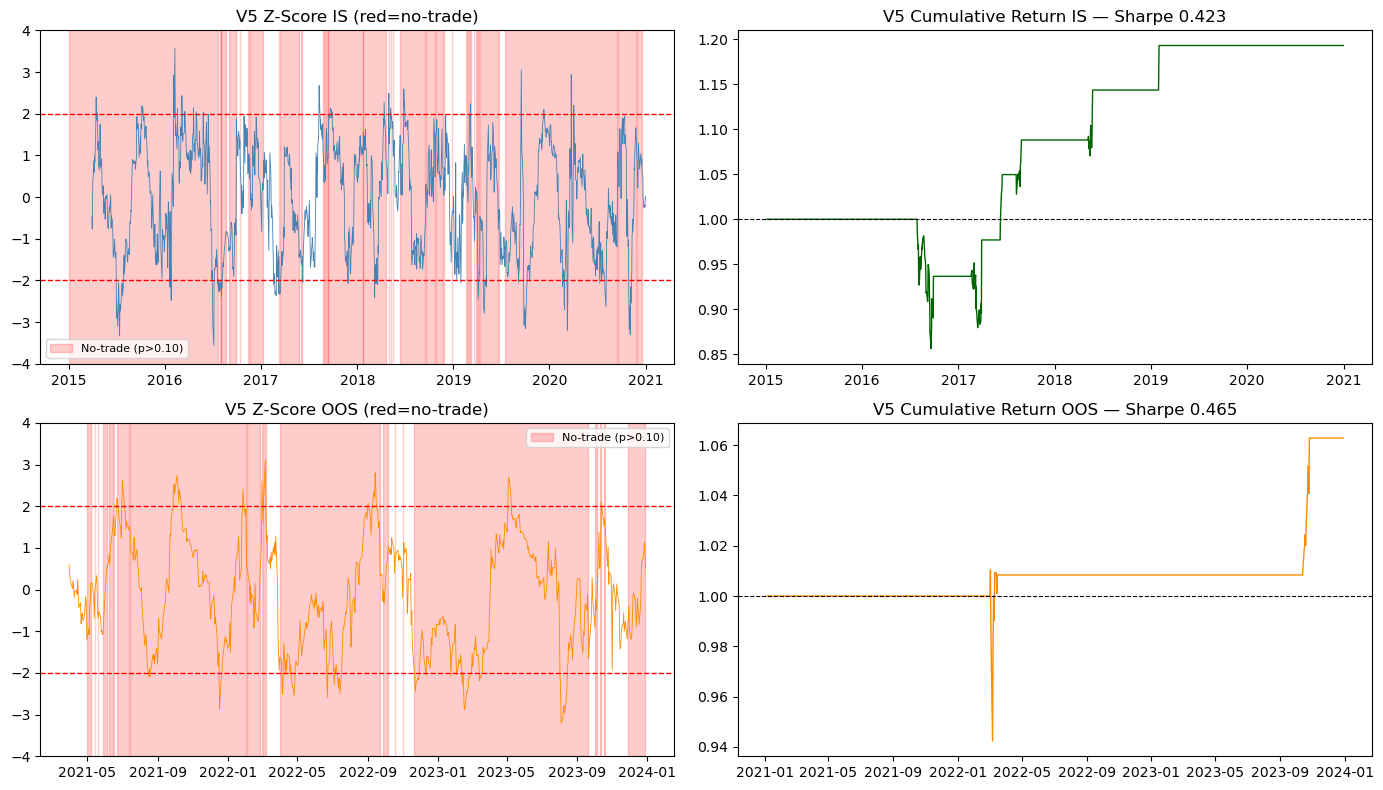

In [14]:
from statsmodels.tsa.stattools import coint

# --- Rolling cointegration p-value (causal) ---
roll_window = 126
full_log_cop = np.log(prices['COP'])
full_log_mpc = np.log(prices['MPC'])

roll_pvals = pd.Series(np.nan, index=prices.index)

print("Computing rolling cointegration p-values... (~30 seconds)")
for i in range(roll_window, len(prices)):
    y_win = full_log_cop.iloc[i-roll_window:i]
    x_win = full_log_mpc.iloc[i-roll_window:i]
    _, pval, _ = coint(y_win, x_win)
    roll_pvals.iloc[i] = pval

coint_active = (roll_pvals < 0.10)

print(f"IS  — % time cointegration active: {coint_active[is_mask].mean():.1%}")
print(f"OOS — % time cointegration active: {coint_active[oos_mask].mean():.1%}")

# --- Plot rolling p-value ---
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_pvals, color='steelblue', linewidth=0.8, label='Rolling 126d p-value')
ax.axhline(0.10, color='red', linestyle='--', linewidth=1, label='p=0.10 threshold')
ax.axvline(pd.Timestamp('2021-01-01'), color='orange', linestyle='--', linewidth=1.2, label='OOS Start')
ax.fill_between(roll_pvals.index, 0, 1,
                where=coint_active.fillna(False),
                alpha=0.15, color='green', label='Trading active')
ax.set_title('COP/MPC Rolling 126-Day Cointegration p-value')
ax.set_ylabel('p-value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- V5 positions ---
def build_positions_coint_filtered(z, coint_flag, entry=2.0, exit=0.5):
    pos = pd.Series(0, index=z.index)
    for i in range(1, len(z)):
        prev = pos.iloc[i-1]
        zi   = z.iloc[i]
        date = z.index[i]
        active = coint_flag.get(date, False)
        if pd.isna(zi):
            pos.iloc[i] = 0
        elif prev != 0:
            if prev ==  1 and zi >= -exit: pos.iloc[i] = 0
            elif prev == -1 and zi <=  exit: pos.iloc[i] = 0
            else: pos.iloc[i] = prev
        elif active:
            if zi >  entry: pos.iloc[i] = -1
            elif zi < -entry: pos.iloc[i] =  1
    return pos

pos_IS_v5  = build_positions_coint_filtered(z_IS_v3,  coint_active[is_mask])
pos_OOS_v5 = build_positions_coint_filtered(z_OOS_v3, coint_active[oos_mask])

ret_IS_v5  = (pos_IS_v5.shift(1)  * spread_ret_IS).dropna()
ret_OOS_v5 = (pos_OOS_v5.shift(1) * spread_ret_OOS).dropna()

m_IS_v5  = metrics(ret_IS_v5)
m_OOS_v5 = metrics(ret_OOS_v5)

# --- Full comparison ---
print("\nFULL VERSION COMPARISON")
print("="*72)
print(f"{'Metric':<18} {'V1 IS':>10} {'V1 OOS':>10} {'V3 IS':>10} {'V3 OOS':>10} {'V5 IS':>10} {'V5 OOS':>10}")
print("-"*72)
v1_IS  = dict(Sharpe=0.704,  Return=0.1417, Vol=0.2012, MaxDD=-0.2568, WinRate=0.2007)
v1_OOS = dict(Sharpe=0.013,  Return=0.0018, Vol=0.1440, MaxDD=-0.2508, WinRate=0.1503)
v3_IS  = dict(Sharpe=1.023,  Return=0.2101, Vol=0.2054, MaxDD=-0.2554, WinRate=0.1775)
v3_OOS = dict(Sharpe=-0.111, Return=-0.0169,Vol=0.1517, MaxDD=-0.2849, WinRate=0.2181)

for k in m_IS_v5:
    fmt = '.3f' if k=='Sharpe' else '.2%'
    print(f"{k:<18} {v1_IS[k]:>10{fmt}} {v1_OOS[k]:>10{fmt}} "
          f"{v3_IS[k]:>10{fmt}} {v3_OOS[k]:>10{fmt}} "
          f"{m_IS_v5[k]:>10{fmt}} {m_OOS_v5[k]:>10{fmt}}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cum_IS_v5  = (1 + ret_IS_v5).cumprod()
cum_OOS_v5 = (1 + ret_OOS_v5).cumprod()

for row, (z, cum, regime_mask, period, color) in enumerate([
    (z_IS_v3,  cum_IS_v5,  is_mask,  'IS',  'darkgreen'),
    (z_OOS_v3, cum_OOS_v5, oos_mask, 'OOS', 'darkorange')
]):
    sh = m_IS_v5['Sharpe'] if period=='IS' else m_OOS_v5['Sharpe']
    axes[row][0].plot(z, color='steelblue' if period=='IS' else 'darkorange', linewidth=0.6)
    axes[row][0].fill_between(z.index, -4, 4,
        where=~coint_active[regime_mask].reindex(z.index).fillna(False),
        alpha=0.2, color='red', label='No-trade (p>0.10)')
    axes[row][0].axhline( 2, color='red', linestyle='--', linewidth=1)
    axes[row][0].axhline(-2, color='red', linestyle='--', linewidth=1)
    axes[row][0].set_title(f'V5 Z-Score {period} (red=no-trade)')
    axes[row][0].set_ylim(-4, 4)
    axes[row][0].legend(fontsize=8)

    axes[row][1].plot(cum, color=color, linewidth=1)
    axes[row][1].axhline(1, color='black', linestyle='--', linewidth=0.8)
    axes[row][1].set_title(f'V5 Cumulative Return {period} — Sharpe {sh:.3f}')

plt.tight_layout()
plt.show()